# Training on Tasks

Fitting tunes a handful of parameters to reproduce one observation. **Training** is the
data-driven sibling: optimise *all* of a network's weights, over many input/target pairs, for
many epochs, so the network learns to perform a **task**. Because brainmass networks are
differentiable, the same backpropagation that fit a single parameter in
{doc}`/tutorials/06_fitting_with_gradients` scales to training a recurrent network.

In this tutorial we train a {class}`~brainmass.HORNSeqNetwork` -- a recurrent network of
harmonic oscillators -- on the bundled **delayed match-to-sample** task. The network sees a cue,
then (after a delay) a probe, and must decide whether they match. You will:

1. load the task from {mod}`brainmass.datasets`,
2. build a HORN classifier and a cross-entropy task loss,
3. optimise its weights over epochs/mini-batches with a `braintools.optim` optimiser, and
4. watch the train/test accuracy climb from chance to near-perfect.

:::{note}
{class}`~brainmass.Fitter` targets *parameter fitting* against a single fixed target. **Task
training** -- minibatching `(inputs, targets)` pairs over epochs, tracking a held-out metric --
is a different loop, so here we drive the {mod}`braintools.optim` optimiser directly. The
**Lessons** at the bottom note this as the gap that a future `Trainer` would close.
:::

In [1]:
import brainmass
import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

brainstate.environ.set(dt=1.0 * u.ms)
brainstate.random.seed(0)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## The task

{func}`brainmass.datasets.delayed_match_task` synthesises a delayed match-to-sample dataset. At
each trial a one-hot **cue** symbol is presented at the first time step; after a delay of blank
steps a one-hot **probe** appears at the last step. The binary target is `1` if the probe
matches the cue and `0` otherwise -- the network must hold the cue in its dynamics across the
delay and compare. We use a 2-symbol alphabet and an 8-step sequence.

inputs : (320, 8, 2) float64   (n_samples, seq_len, n_symbols)
targets: (320,) int64  balance = 0.5


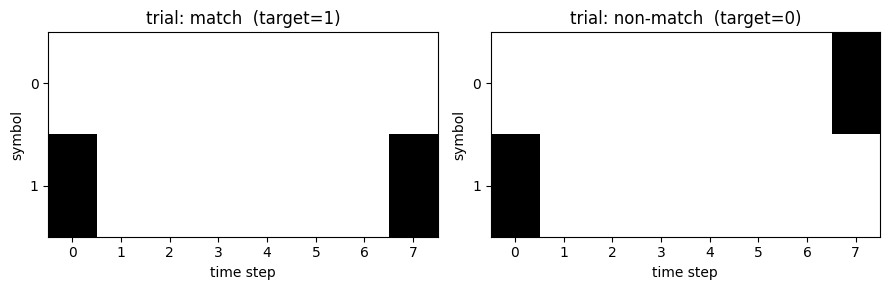

In [2]:
inputs_np, targets_np = brainmass.datasets.delayed_match_task(
    n_samples=320, seq_len=8, n_symbols=2, seed=0,
)
print("inputs :", inputs_np.shape, inputs_np.dtype, "  (n_samples, seq_len, n_symbols)")
print("targets:", targets_np.shape, targets_np.dtype, " balance =", float(targets_np.mean()))

inputs = jnp.asarray(inputs_np, dtype=jnp.float32)
targets = jnp.asarray(targets_np, dtype=jnp.int32)

# Hold out a test split.
n_train = 256
X_train, y_train = inputs[:n_train], targets[:n_train]
X_test, y_test = inputs[n_train:], targets[n_train:]
n_symbols = inputs.shape[2]

# Visualise one matching and one non-matching trial.
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, idx, name in [(axes[0], int(np.argmax(targets_np == 1)), 'match'),
                      (axes[1], int(np.argmax(targets_np == 0)), 'non-match')]:
    ax.imshow(inputs_np[idx].T, aspect='auto', cmap='Greys', interpolation='nearest')
    ax.set_title(f"trial: {name}  (target={int(targets_np[idx])})")
    ax.set_xlabel('time step'); ax.set_ylabel('symbol')
    ax.set_yticks(range(n_symbols))
plt.tight_layout()
plt.show()

## The network

A {class}`~brainmass.HORNSeqNetwork` maps an input *sequence* `(T, n_input)` to a single output
vector by running its oscillator dynamics across the sequence and reading out the final state.
We give it two output units (match / non-match logits). The `alpha` (excitability) is raised
from its default so the oscillators respond strongly enough to learn this task quickly.

The network writes its hidden states *in place* during the forward pass, and
{meth}`~brainmass.HORNSeqNetwork.init_state` allocates them at the unbatched shape. To process a
mini-batch we reset the hidden states to the batch shape before each forward pass and feed the
sequence as `(T, batch, n_input)`.

In [3]:
net = brainmass.HORNSeqNetwork(
    n_input=n_symbols,
    n_hidden=64,
    n_output=2,
    alpha=0.2,                    # excitability (raised from the 0.04 default)
    omega=2 * np.pi / 28,
)
brainstate.nn.init_all_states(net)

def reset_hidden(batch_size):
    # HORN allocates hidden states unbatched; broadcast them to the batch shape.
    for layer in net.layers:
        shape = (batch_size,) + tuple(layer.horn.in_size)
        layer.horn.x.value = jnp.zeros(shape)
        layer.horn.y.value = jnp.zeros(shape)

def logits(batch_inputs):                 # batch_inputs: (B, T, n_symbols) -> (B, 2)
    reset_hidden(batch_inputs.shape[0])
    seq = jnp.transpose(batch_inputs, (1, 0, 2))   # (T, B, n_symbols): time leads
    return net(seq)

# A trainable weight = a ParamState. HORN's Linear layers expose several.
weights = net.states(brainstate.ParamState)
print("trainable weight tensors:", len(weights))

trainable weight tensors: 3


## The task loss and training loop

The loss is softmax cross-entropy between the network's logits and the binary target, with
accuracy tracked alongside. We register the trainable weights with an Adam optimiser and, each
step, take the gradient of the loss through the whole recurrent rollout
({func}`brainstate.transform.grad`) and apply it ({meth}`~braintools.optim.Adam.step`) -- the
canonical brainmass training primitive, jitted for speed.

This is the same backprop-through-the-solve as the fitting tutorials; the only new ingredients
are **minibatching** and the **epoch loop**.

In [4]:
optimizer = braintools.optim.Adam(lr=3e-2)
optimizer.register_trainable_weights(weights)

def loss_and_acc(batch_inputs, batch_targets):
    lg = logits(batch_inputs)
    logp = jax.nn.log_softmax(lg, axis=-1)
    ce = -jnp.mean(logp[jnp.arange(batch_targets.shape[0]), batch_targets])
    acc = jnp.mean(jnp.argmax(lg, axis=-1) == batch_targets)
    return ce, acc

@brainstate.transform.jit
def train_step(batch_inputs, batch_targets):
    grad_fn = brainstate.transform.grad(
        lambda: loss_and_acc(batch_inputs, batch_targets),
        weights, has_aux=True, return_value=True,
    )
    grads, loss, acc = grad_fn()
    optimizer.step(grads)
    return loss, acc

@brainstate.transform.jit
def evaluate(batch_inputs, batch_targets):
    return loss_and_acc(batch_inputs, batch_targets)

n_epochs = 20
batch_size = 32
history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(n_epochs):
    perm = np.random.RandomState(epoch).permutation(n_train)
    losses, accs = [], []
    for start in range(0, n_train, batch_size):
        idx = perm[start:start + batch_size]
        if len(idx) < batch_size:
            continue
        loss, acc = train_step(X_train[idx], y_train[idx])
        losses.append(float(loss)); accs.append(float(acc))
    _, test_acc = evaluate(X_test, y_test)
    history['epoch'].append(epoch)
    history['train_loss'].append(float(np.mean(losses)))
    history['train_acc'].append(float(np.mean(accs)))
    history['test_acc'].append(float(test_acc))
    if epoch % 4 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:2d}: train_loss={np.mean(losses):.4f} "
              f"train_acc={np.mean(accs):.3f}  test_acc={float(test_acc):.3f}")

epoch  0: train_loss=1.1386 train_acc=0.543  test_acc=0.516


epoch  4: train_loss=0.6885 train_acc=0.562  test_acc=0.516


epoch  8: train_loss=0.6811 train_acc=0.676  test_acc=0.750


epoch 12: train_loss=0.5739 train_acc=0.785  test_acc=1.000


epoch 16: train_loss=0.2497 train_acc=1.000  test_acc=1.000


epoch 19: train_loss=0.1423 train_acc=1.000  test_acc=1.000


## Results

The network starts at chance (~50%, a binary task) and -- as gradient descent shapes its
recurrent weights to hold the cue across the delay -- climbs to near-perfect accuracy on both
the training and held-out sets.

final train accuracy: 100.0%
final test  accuracy: 100.0%


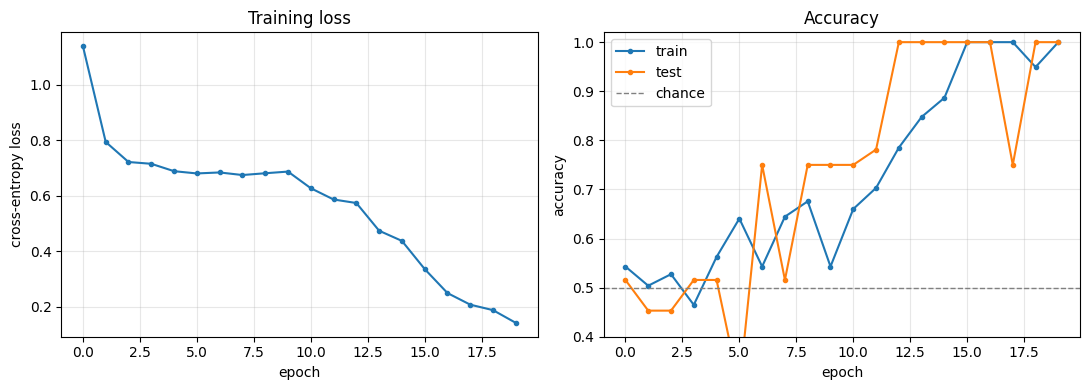

In [5]:
final_train = history['train_acc'][-1]
final_test = history['test_acc'][-1]
print(f"final train accuracy: {final_train:.1%}")
print(f"final test  accuracy: {final_test:.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history['epoch'], history['train_loss'], marker='.')
ax1.set_xlabel('epoch'); ax1.set_ylabel('cross-entropy loss')
ax1.set_title('Training loss'); ax1.grid(alpha=0.3)

ax2.plot(history['epoch'], history['train_acc'], marker='.', label='train')
ax2.plot(history['epoch'], history['test_acc'], marker='.', label='test')
ax2.axhline(0.5, color='grey', ls='--', lw=1, label='chance')
ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy')
ax2.set_ylim(0.4, 1.02); ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Lessons: the `Trainer` gap

This notebook used {mod}`braintools.optim` directly because {class}`~brainmass.Fitter` does not
yet cover **task training**:

- `Fitter` fits parameters against a **single fixed target** via one `predict(model) -> scalar`
  call. Task training needs **minibatched `(inputs, targets)` pairs**, an **epoch loop**, and a
  **held-out metric** -- none of which `Fitter` exposes.
- We also had to reset the network's hidden states to the batch shape by hand
  (`reset_hidden`), because {class}`~brainmass.HORNSeqNetwork` allocates them unbatched. A
  training abstraction would own batched state initialisation.

A future `Trainer` -- the data-driven counterpart to `Fitter` -- would wrap exactly the loop
written above: dataset minibatching, the jitted `grad -> optimizer.step`, per-epoch
train/validation metrics, and batched state handling. Until then, the loop in this notebook is
the recommended pattern for training a brainmass network on a task. (See
{doc}`/data_driven/index` for the data-driven roadmap.)

## Summary

- **Training** optimises a whole network's weights over many `(input, target)` pairs and epochs,
  using the same backprop-through-the-solve as fitting.
- A {class}`~brainmass.HORNSeqNetwork` learns the delayed match-to-sample task from
  {mod}`brainmass.datasets` to near-perfect accuracy in ~20 epochs.
- {mod}`braintools.optim` provides the optimiser; the `grad -> step` loop is jitted for speed.
- A dedicated `Trainer` is the natural next abstraction; for now, drive the optimiser directly.

## Next steps

- {doc}`/tutorials/06_fitting_with_gradients` -- the gradient machinery behind training.
- {doc}`/data_driven/index` -- the data-driven narrative and roadmap.
- {doc}`/reference/horn` -- {class}`~brainmass.HORNSeqNetwork` API.